# 🧠 Deep Learning Final Project — CNN Image Classification

> Complete implementation covering all three parts:
> - **Part 1:** Training CNNs from Scratch (Steps 1-3)
> - **Part 2:** Transfer Learning with Your Own Pretrained Model (Steps 4-5)
> - **Part 3:** Transfer Learning with ResNet50 (Steps 6-7)

In [ ]:
# ============================================================================
# IMPORTS AND SETUP
# ============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# 📦 PART 1 — Training a CNN from Scratch

> **Goal:** Build and train CNN architectures from scratch, comparing different architectures, optimizers, and hyperparameters.

## 🔧 Step 1 — Architecture & Optimization

### 1.1 Data Setup

In [ ]:
# ============================================================================
# 1.1 DATA LOADING AND PREPARATION
# ============================================================================

# Path to the drive directory in which the training data is
DATA_PATH = '/content/drive/MyDrive/data'

# Define transforms for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the entire dataset
full_dataset = datasets.ImageFolder(root=DATA_PATH, transform=transform)

# Get class names and number of classes
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Total images: {len(full_dataset)}")

# Define split ratios (70/15/15)
train_ratio, valid_ratio, test_ratio = 0.7, 0.15, 0.15

# Calculate split sizes
total_size = len(full_dataset)
train_size = int(train_ratio * total_size)
valid_size = int(valid_ratio * total_size)
test_size = total_size - train_size - valid_size

# Split the dataset
train_dataset, valid_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, valid_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\nDataset splits:")
print(f"  Train: {len(train_dataset)}")
print(f"  Valid: {len(valid_dataset)}")
print(f"  Test:  {len(test_dataset)}")

Classes: ['COLE', 'DBRMN', 'GRDNSTR', 'GRMNSHP', 'GRNDL', 'MLNS', 'RTWLR']
Number of classes: 7
Total images: 1069

Dataset splits:
  Train: 748
  Valid: 160
  Test:  161


In [ ]:
# Create DataLoaders
def create_dataloaders(batch_size=64):
    """Create train, validation, and test DataLoaders."""
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

# Default batch size
BATCH_SIZE = 64
train_loader, valid_loader, test_loader = create_dataloaders(BATCH_SIZE)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 64
Training batches: 12
Validation batches: 3
Test batches: 3


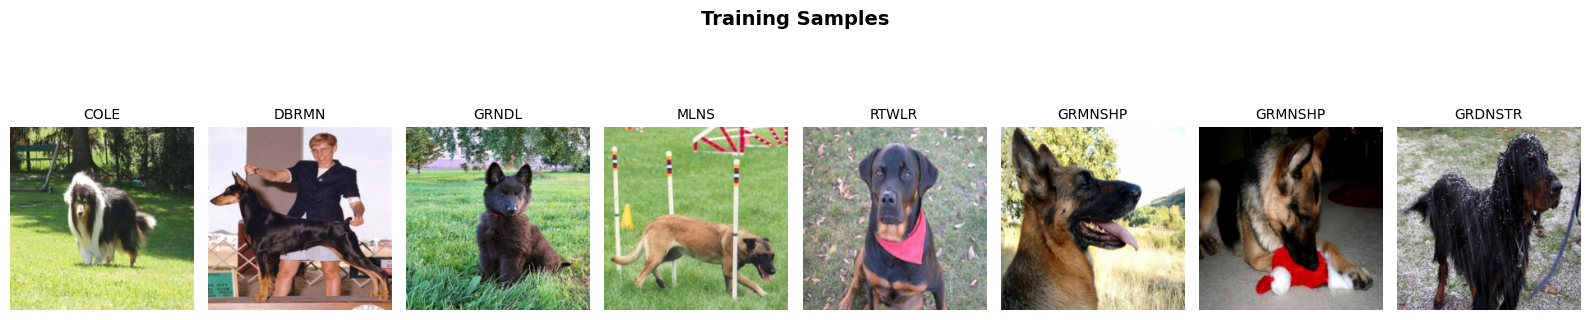

In [ ]:
# Visualize sample images
def visualize_samples(dataset, n_samples=8, title="Sample Images"):
    """Visualize sample images from the dataset."""
    fig, axes = plt.subplots(1, n_samples, figsize=(16, 4))

    # Get random samples
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        # Denormalize for visualization
        img = img.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(class_names[label], fontsize=10)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset, title="Training Samples")

### 1.2 CNN Architectures

**Architecture A (Shallow CNN):** 2 convolutional layers + 2 FC layers
- Simpler model, fewer parameters, faster training
- Good baseline, may underfit on complex data

**Architecture B (Deep CNN):** 4 convolutional layers + 3 FC layers  
- More capacity to learn complex features
- May overfit on small datasets, needs regularization

In [ ]:
# ============================================================================
# 1.2 CNN ARCHITECTURES
# ============================================================================

class ShallowCNN(nn.Module):
    """
    Architecture A: Shallow CNN
    2 Conv layers + 2 FC layers
    Input: 224x224 RGB images → Output: num_classes
    """
    def __init__(self, num_classes=7):
        super(ShallowCNN, self).__init__()

        # Convolutional network part
        self.features = nn.Sequential(
            # Conv1: 3 → 32 channels
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 → 112

            # Conv2: 32 → 64 channels
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 → 56
        )

        # Fully connected neural network part
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class DeepCNN(nn.Module):
    """
    Architecture B: Deep CNN
    4 Conv layers + 3 FC layers
    Input: 224x224 RGB images → Output: num_classes
    """
    def __init__(self, num_classes=7):
        super(DeepCNN, self).__init__()

        self.features = nn.Sequential(
            # Conv1: 3 → 32 channels
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 → 112

            # Conv2: 32 → 64 channels
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 → 56

            # Conv3: 64 → 128 channels
            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 → 28

            # Conv4: 128 → 32 channels
            nn.Conv2d(128, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 → 14
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Verify architectures
def count_parameters(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

shallow_model = ShallowCNN(num_classes)
deep_model = DeepCNN(num_classes)

print("=" * 50)
print("SHALLOW CNN ARCHITECTURE")
print("=" * 50)
print(f"Total parameters: {count_parameters(shallow_model):,}")
print(shallow_model)

print("\n" + "=" * 50)
print("DEEP CNN ARCHITECTURE")
print("=" * 50)
print(f"Total parameters: {count_parameters(deep_model):,}")
print(deep_model)

SHALLOW CNN ARCHITECTURE
Total parameters: 25,744,839
ShallowCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)

DEEP CNN ARCHITECTURE
Total parameters: 1,168,359
DeepCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
   

### 1.3 Training Loop and Utilities

In [ ]:
# ============================================================================
# TRAINING UTILITIES
# ============================================================================

def train_model(model, train_loader, valid_loader, optimizer, num_epochs=10,
                scheduler=None, verbose=True):
    """
    Train a PyTorch model with training and validation loops.

    Args:
        model: PyTorch model to train
        train_loader: Training DataLoader
        valid_loader: Validation DataLoader
        optimizer: PyTorch optimizer
        num_epochs: Number of training epochs
        scheduler: Learning rate scheduler (optional)
        verbose: Print progress if True

    Returns:
        history: dict with train/valid loss and accuracy per epoch
    """
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    history = {
        'train_loss': [], 'valid_loss': [],
        'train_acc': [], 'valid_acc': []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        # Validation phase
        model.eval()
        valid_loss, valid_correct, valid_total = 0.0, 0, 0

        with torch.no_grad():
            for x_batch, y_batch in valid_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                outputs = model(x_batch)
                loss = loss_fn(outputs, y_batch)

                valid_loss += loss.item() * x_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                valid_total += y_batch.size(0)
                valid_correct += (predicted == y_batch).sum().item()

        # Calculate metrics
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_valid_loss = valid_loss / valid_total
        epoch_valid_acc = valid_correct / valid_total

        # Store history
        history['train_loss'].append(epoch_train_loss)
        history['valid_loss'].append(epoch_valid_loss)
        history['train_acc'].append(epoch_train_acc)
        history['valid_acc'].append(epoch_valid_acc)

        # Learning rate scheduler step
        if scheduler:
            scheduler.step()

        # Print progress
        if verbose:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} - "
                  f"Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_acc:.4f}")

    training_time = time.time() - start_time
    history['training_time'] = training_time

    if verbose:
        print(f"\nTotal training time: {training_time:.2f}s")

    return history


def evaluate_model(model, test_loader):
    """Evaluate model on test set."""
    model = model.to(device)
    model.eval()

    test_correct, test_total = 0, 0
    all_predictions, all_labels = [], []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            _, predicted = torch.max(outputs, 1)

            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    accuracy = test_correct / test_total
    return accuracy, all_predictions, all_labels


def plot_training_history(history, title="Training History"):
    """Plot training and validation curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['valid_loss'], label='Valid Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['valid_acc'], label='Valid Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_comparison(histories, labels, title="Model Comparison"):
    """Plot comparison of multiple training histories."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for i, (hist, label) in enumerate(zip(histories, labels)):
        # Training Loss
        axes[0, 0].plot(hist['train_loss'], label=label, color=colors[i], marker='o')
        # Validation Loss
        axes[0, 1].plot(hist['valid_loss'], label=label, color=colors[i], marker='s')
        # Training Accuracy
        axes[1, 0].plot(hist['train_acc'], label=label, color=colors[i], marker='o')
        # Validation Accuracy
        axes[1, 1].plot(hist['valid_acc'], label=label, color=colors[i], marker='s')

    titles = ['Training Loss', 'Validation Loss', 'Training Accuracy', 'Validation Accuracy']
    ylabels = ['Loss', 'Loss', 'Accuracy', 'Accuracy']

    for idx, ax in enumerate(axes.flat):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabels[idx])
        ax.set_title(titles[idx], fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_compare(history1, history2, label1='Experiment 1', label2='Experiment 2',
                 title_prefix='Comparison'):
    """
    Plot side-by-side comparison of two training histories.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss comparison
    axes[0].plot(history1['train_loss'], label=f'Train Loss ({label1})', marker='o')
    axes[0].plot(history1['valid_loss'], label=f'Valid Loss ({label1})', marker='s')
    axes[0].plot(history2['train_loss'], label=f'Train Loss ({label2})', marker='o', linestyle='--')
    axes[0].plot(history2['valid_loss'], label=f'Valid Loss ({label2})', marker='s', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title_prefix}: Loss')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Accuracy comparison
    axes[1].plot(history1['train_acc'], label=f'Train Acc ({label1})', marker='o')
    axes[1].plot(history1['valid_acc'], label=f'Valid Acc ({label1})', marker='s')
    axes[1].plot(history2['train_acc'], label=f'Train Acc ({label2})', marker='o', linestyle='--')
    axes[1].plot(history2['valid_acc'], label=f'Valid Acc ({label2})', marker='s', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title_prefix}: Accuracy')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print("Training utilities defined successfully!")

Training utilities defined successfully!


### 1.4 Optimizer Comparison: Adam vs SGD

In [ ]:
# ============================================================================
# 1.4 OPTIMIZER COMPARISON: SHALLOW CNN
# ============================================================================

NUM_EPOCHS = 15
LR = 0.001

# Train Shallow CNN with SGD
print("Training Shallow CNN with SGD + Momentum...")
shallow_sgd = ShallowCNN(num_classes)
optimizer_sgd = optim.SGD(shallow_sgd.parameters(), lr=LR, momentum=0.9)
history_shallow_sgd = train_model(shallow_sgd, train_loader, valid_loader,
                                   optimizer_sgd, num_epochs=NUM_EPOCHS)

Training Shallow CNN with SGD + Momentum...
Epoch [1/15] - Train Loss: 1.9381, Train Acc: 0.1604 - Valid Loss: 1.9076, Valid Acc: 0.2188
Epoch [2/15] - Train Loss: 1.8496, Train Acc: 0.2594 - Valid Loss: 1.8620, Valid Acc: 0.2812
Epoch [3/15] - Train Loss: 1.7231, Train Acc: 0.3382 - Valid Loss: 1.8488, Valid Acc: 0.2250
Epoch [4/15] - Train Loss: 1.6217, Train Acc: 0.3449 - Valid Loss: 1.8607, Valid Acc: 0.2938
Epoch [5/15] - Train Loss: 1.5334, Train Acc: 0.4024 - Valid Loss: 1.8797, Valid Acc: 0.2250
Epoch [6/15] - Train Loss: 1.4910, Train Acc: 0.4425 - Valid Loss: 1.8689, Valid Acc: 0.2188
Epoch [7/15] - Train Loss: 1.3664, Train Acc: 0.5013 - Valid Loss: 1.9255, Valid Acc: 0.2500
Epoch [8/15] - Train Loss: 1.2535, Train Acc: 0.5521 - Valid Loss: 2.0030, Valid Acc: 0.2437
Epoch [9/15] - Train Loss: 1.1417, Train Acc: 0.6110 - Valid Loss: 1.9537, Valid Acc: 0.2437
Epoch [10/15] - Train Loss: 0.9663, Train Acc: 0.6778 - Valid Loss: 2.1414, Valid Acc: 0.2375
Epoch [11/15] - Train Los

In [ ]:
# Train Shallow CNN with Adam
print("Training Shallow CNN with Adam...")
shallow_adam = ShallowCNN(num_classes)
optimizer_adam = optim.Adam(shallow_adam.parameters(), lr=LR)
history_shallow_adam = train_model(shallow_adam, train_loader, valid_loader,
                                    optimizer_adam, num_epochs=NUM_EPOCHS)

Training Shallow CNN with Adam...
Epoch [1/15] - Train Loss: 6.0043, Train Acc: 0.1631 - Valid Loss: 1.9420, Valid Acc: 0.1812
Epoch [2/15] - Train Loss: 1.9482, Train Acc: 0.1457 - Valid Loss: 1.9423, Valid Acc: 0.1812
Epoch [3/15] - Train Loss: 1.9478, Train Acc: 0.1457 - Valid Loss: 1.9422, Valid Acc: 0.1812
Epoch [4/15] - Train Loss: 1.9382, Train Acc: 0.1484 - Valid Loss: 1.9391, Valid Acc: 0.1500
Epoch [5/15] - Train Loss: 1.8889, Train Acc: 0.2112 - Valid Loss: 1.9009, Valid Acc: 0.2188
Epoch [6/15] - Train Loss: 1.7155, Train Acc: 0.3743 - Valid Loss: 1.9666, Valid Acc: 0.2000
Epoch [7/15] - Train Loss: 1.4404, Train Acc: 0.4893 - Valid Loss: 1.9471, Valid Acc: 0.2125
Epoch [8/15] - Train Loss: 0.9794, Train Acc: 0.6711 - Valid Loss: 2.3859, Valid Acc: 0.2562
Epoch [9/15] - Train Loss: 0.5193, Train Acc: 0.8610 - Valid Loss: 3.1760, Valid Acc: 0.2313
Epoch [10/15] - Train Loss: 0.2242, Train Acc: 0.9412 - Valid Loss: 3.6973, Valid Acc: 0.2375
Epoch [11/15] - Train Loss: 0.0832,

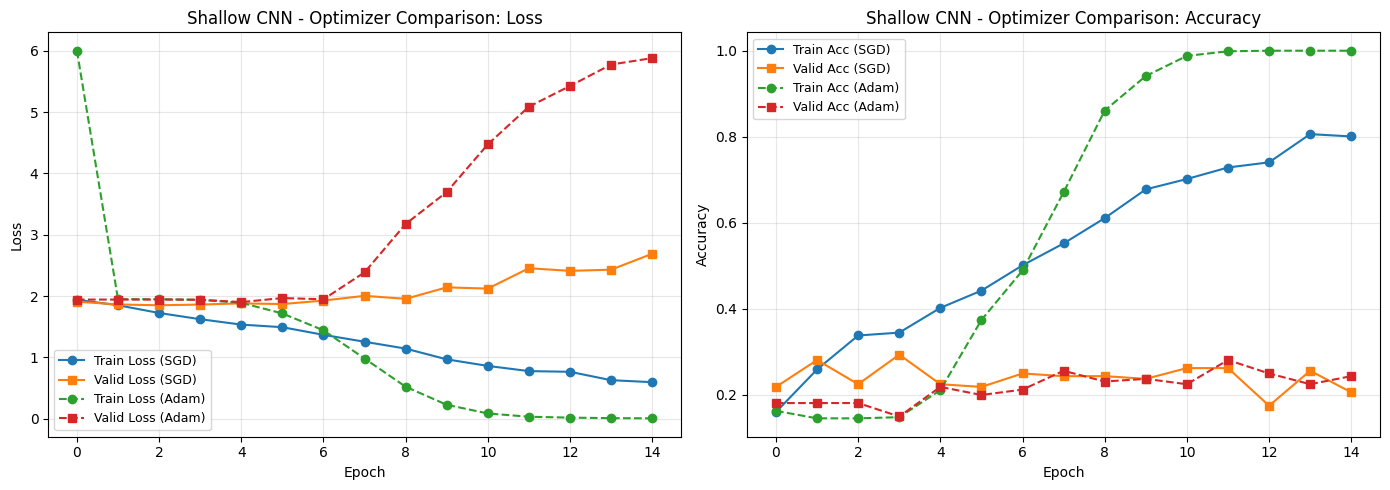

In [ ]:
# Plot Shallow CNN optimizer comparison
plot_compare(history_shallow_sgd, history_shallow_adam,
             label1='SGD', label2='Adam',
             title_prefix='Shallow CNN - Optimizer Comparison')

### Shallow Architecture: Training Results Analysis
Significant overfitting was observed with both optimization algorithms.

In [ ]:
# ============================================================================
# 1.4 OPTIMIZER COMPARISON: DEEP CNN
# ============================================================================

# Train Deep CNN with SGD
print("Training Deep CNN with SGD + Momentum...")
deep_sgd = DeepCNN(num_classes)
optimizer_sgd = optim.SGD(deep_sgd.parameters(), lr=LR, momentum=0.9)
history_deep_sgd = train_model(deep_sgd, train_loader, valid_loader,
                                optimizer_sgd, num_epochs=NUM_EPOCHS)

Training Deep CNN with SGD + Momentum...
Epoch [1/15] - Train Loss: 1.9450, Train Acc: 0.1564 - Valid Loss: 1.9502, Valid Acc: 0.1250
Epoch [2/15] - Train Loss: 1.9448, Train Acc: 0.1564 - Valid Loss: 1.9500, Valid Acc: 0.1250
Epoch [3/15] - Train Loss: 1.9446, Train Acc: 0.1537 - Valid Loss: 1.9497, Valid Acc: 0.1313
Epoch [4/15] - Train Loss: 1.9444, Train Acc: 0.1551 - Valid Loss: 1.9495, Valid Acc: 0.1313
Epoch [5/15] - Train Loss: 1.9441, Train Acc: 0.1591 - Valid Loss: 1.9493, Valid Acc: 0.1313
Epoch [6/15] - Train Loss: 1.9440, Train Acc: 0.1658 - Valid Loss: 1.9489, Valid Acc: 0.1437
Epoch [7/15] - Train Loss: 1.9436, Train Acc: 0.1725 - Valid Loss: 1.9486, Valid Acc: 0.1437
Epoch [8/15] - Train Loss: 1.9434, Train Acc: 0.1818 - Valid Loss: 1.9485, Valid Acc: 0.1437
Epoch [9/15] - Train Loss: 1.9430, Train Acc: 0.1898 - Valid Loss: 1.9479, Valid Acc: 0.1562
Epoch [10/15] - Train Loss: 1.9426, Train Acc: 0.1952 - Valid Loss: 1.9476, Valid Acc: 0.1562
Epoch [11/15] - Train Loss: 

In [ ]:
# Train Deep CNN with Adam
print("Training Deep CNN with Adam...")
deep_adam = DeepCNN(num_classes)
optimizer_adam = optim.Adam(deep_adam.parameters(), lr=LR)
history_deep_adam = train_model(deep_adam, train_loader, valid_loader,
                                 optimizer_adam, num_epochs=NUM_EPOCHS)

Training Deep CNN with Adam...
Epoch [1/15] - Train Loss: 1.9370, Train Acc: 0.1471 - Valid Loss: 1.9210, Valid Acc: 0.2125
Epoch [2/15] - Train Loss: 1.8697, Train Acc: 0.2246 - Valid Loss: 1.8809, Valid Acc: 0.2562
Epoch [3/15] - Train Loss: 1.8329, Train Acc: 0.2527 - Valid Loss: 1.8298, Valid Acc: 0.2687
Epoch [4/15] - Train Loss: 1.7329, Train Acc: 0.3021 - Valid Loss: 1.8016, Valid Acc: 0.3750
Epoch [5/15] - Train Loss: 1.7220, Train Acc: 0.2874 - Valid Loss: 1.8568, Valid Acc: 0.2750
Epoch [6/15] - Train Loss: 1.6125, Train Acc: 0.3516 - Valid Loss: 1.8101, Valid Acc: 0.3375
Epoch [7/15] - Train Loss: 1.4899, Train Acc: 0.4184 - Valid Loss: 1.8075, Valid Acc: 0.3063
Epoch [8/15] - Train Loss: 1.3779, Train Acc: 0.4679 - Valid Loss: 1.8621, Valid Acc: 0.3187
Epoch [9/15] - Train Loss: 1.2434, Train Acc: 0.5241 - Valid Loss: 2.1627, Valid Acc: 0.2437
Epoch [10/15] - Train Loss: 1.0054, Train Acc: 0.6457 - Valid Loss: 3.2445, Valid Acc: 0.2687
Epoch [11/15] - Train Loss: 0.8376, Tr

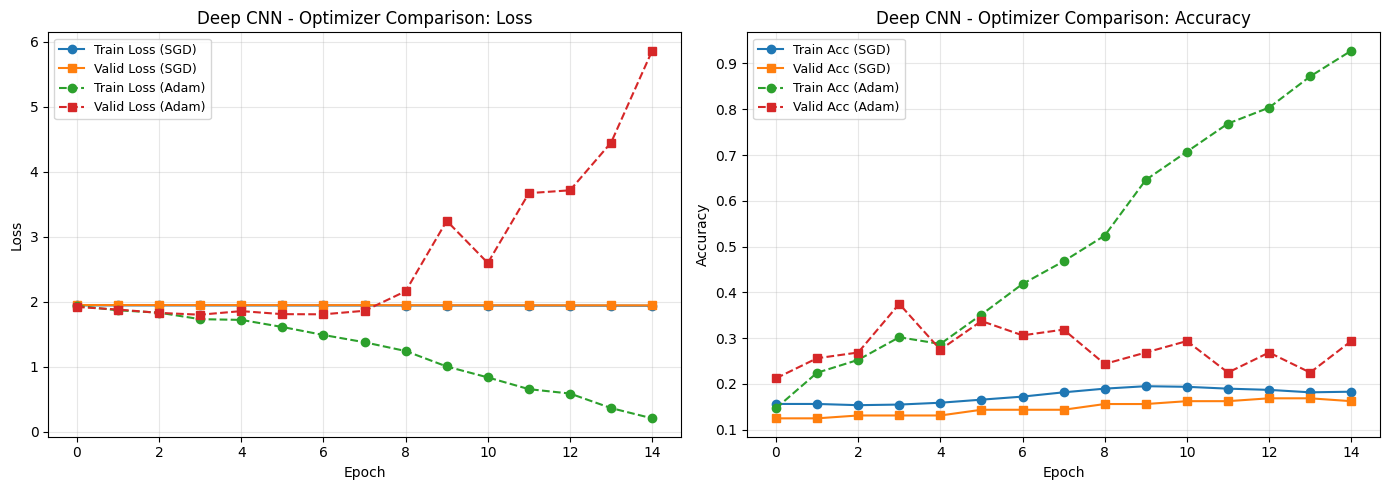

In [ ]:
# Plot Deep CNN optimizer comparison
plot_compare(history_deep_sgd, history_deep_adam,
             label1='SGD', label2='Adam',
             title_prefix='Deep CNN - Optimizer Comparison')

### Deep Architecture: Training Results Analysis

The deep neural network using SGD was unable to learn effectively, as both training and validation losses stayed constant across all epochs. When switching to the Adam optimizer, the training loss decreased and accuracy improved; however, the validation set continued to show high loss and low accuracy, revealing substantial overfitting.

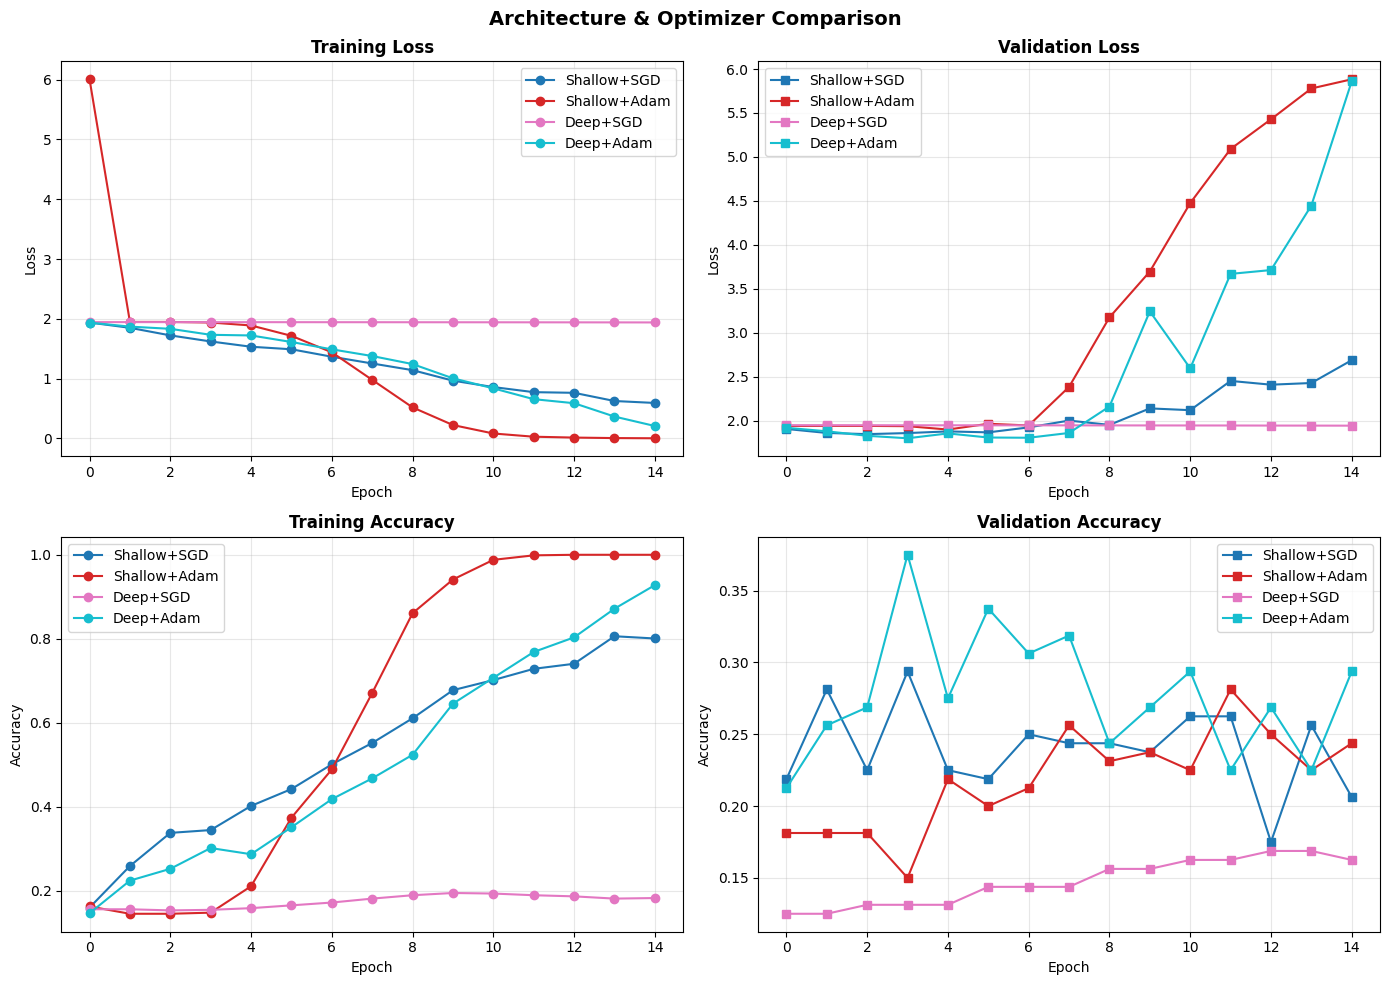

In [ ]:
# Compare all models
all_histories = [history_shallow_sgd, history_shallow_adam, history_deep_sgd, history_deep_adam]
all_labels = ['Shallow+SGD', 'Shallow+Adam', 'Deep+SGD', 'Deep+Adam']
plot_comparison(all_histories, all_labels, title="Architecture & Optimizer Comparison")

### 1.5 Hyperparameter Tuning: Learning Rate

#### 1.5.1.1 Shallow CNN SGD - Learning Rate Experiments

In [ ]:
def test_lr(model_type='shallow', optimizer_type='sgd', num_epochs=10):
    """
    Test different learning rates [0.1, 0.01, 0.001, 0.0001] on a CNN model.

    Args:
        model_type: 'shallow' or 'deep' (default: 'shallow')
        optimizer_type: 'sgd' or 'adam' (default: 'sgd')
        num_epochs: Number of training epochs (default: 10)

    Returns:
        list: Training histories for each learning rate tested
    """
    learning_rates = [0.1, 0.01, 0.001, 0.0001]
    lr_histories = []

    for lr in learning_rates:
        print(f"\n{'='*50}")
        print(f"Training with learning rate: {lr}")
        print(f"{'='*50}")

        model = ShallowCNN(num_classes) if model_type == 'shallow' else DeepCNN(num_classes)
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9) if optimizer_type == 'sgd' else optim.Adam(model.parameters(), lr=lr)

        history = train_model(model, train_loader, valid_loader, optimizer,
                              num_epochs=num_epochs, verbose=False)
        lr_histories.append(history)

        print(f"Final Valid Acc: {history['valid_acc'][-1]:.4f}")

    print("\nLearning rate experiments completed!")
    return lr_histories

In [ ]:
# ============================================================================
# 1.5.1.1 SHALLOW CNN SGD LEARNING RATE EXPERIMENTS
# ============================================================================

learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_histories = test_lr(model_type='shallow', optimizer_type='sgd', num_epochs=NUM_EPOCHS)


Training with learning rate: 0.1
Final Valid Acc: 0.1688

Training with learning rate: 0.01
Final Valid Acc: 0.2875

Training with learning rate: 0.001
Final Valid Acc: 0.2125

Training with learning rate: 0.0001
Final Valid Acc: 0.2250

Learning rate experiments completed!


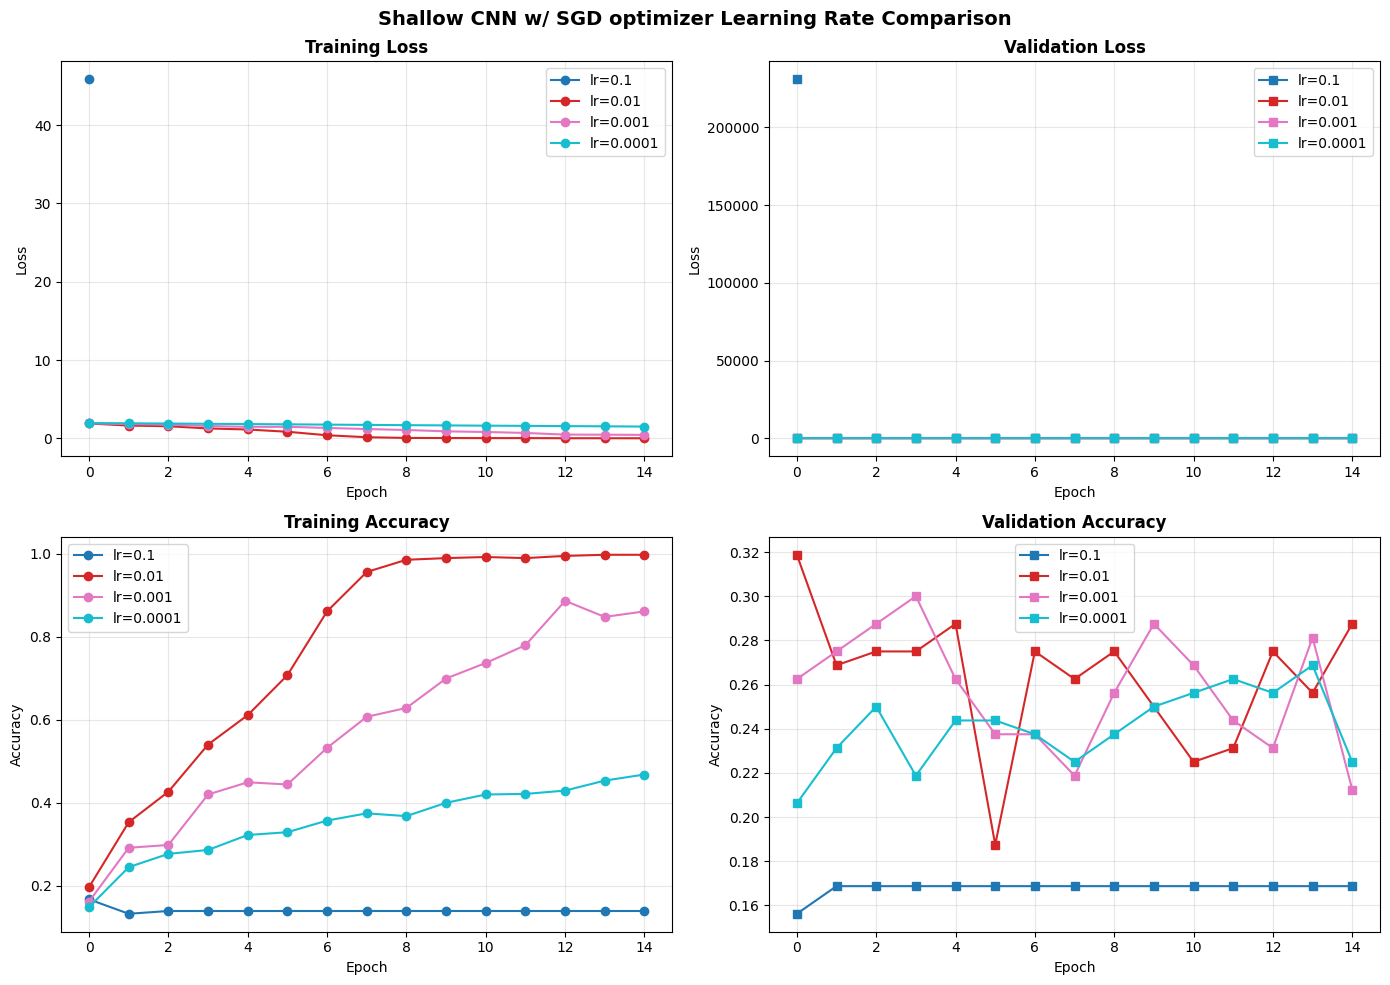

In [ ]:
# Plot learning rate comparison
plot_comparison(lr_histories, [f'lr={lr}' for lr in learning_rates],
                title="Shallow CNN w/ SGD optimizer Learning Rate Comparison")

#### 1.5.1.2 Shallow CNN Adam - Learning Rate Experiments

In [ ]:
# ============================================================================
# 1.5.1.2 SHALLOW CNN ADAM LEARNING RATE EXPERIMENTS
# ============================================================================

learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_histories = test_lr(model_type='shallow', optimizer_type='adam', num_epochs=NUM_EPOCHS)


Training with learning rate: 0.1
Final Valid Acc: 0.1500

Training with learning rate: 0.01
Final Valid Acc: 0.1562

Training with learning rate: 0.001
Final Valid Acc: 0.1562

Training with learning rate: 0.0001
Final Valid Acc: 0.2687

Learning rate experiments completed!


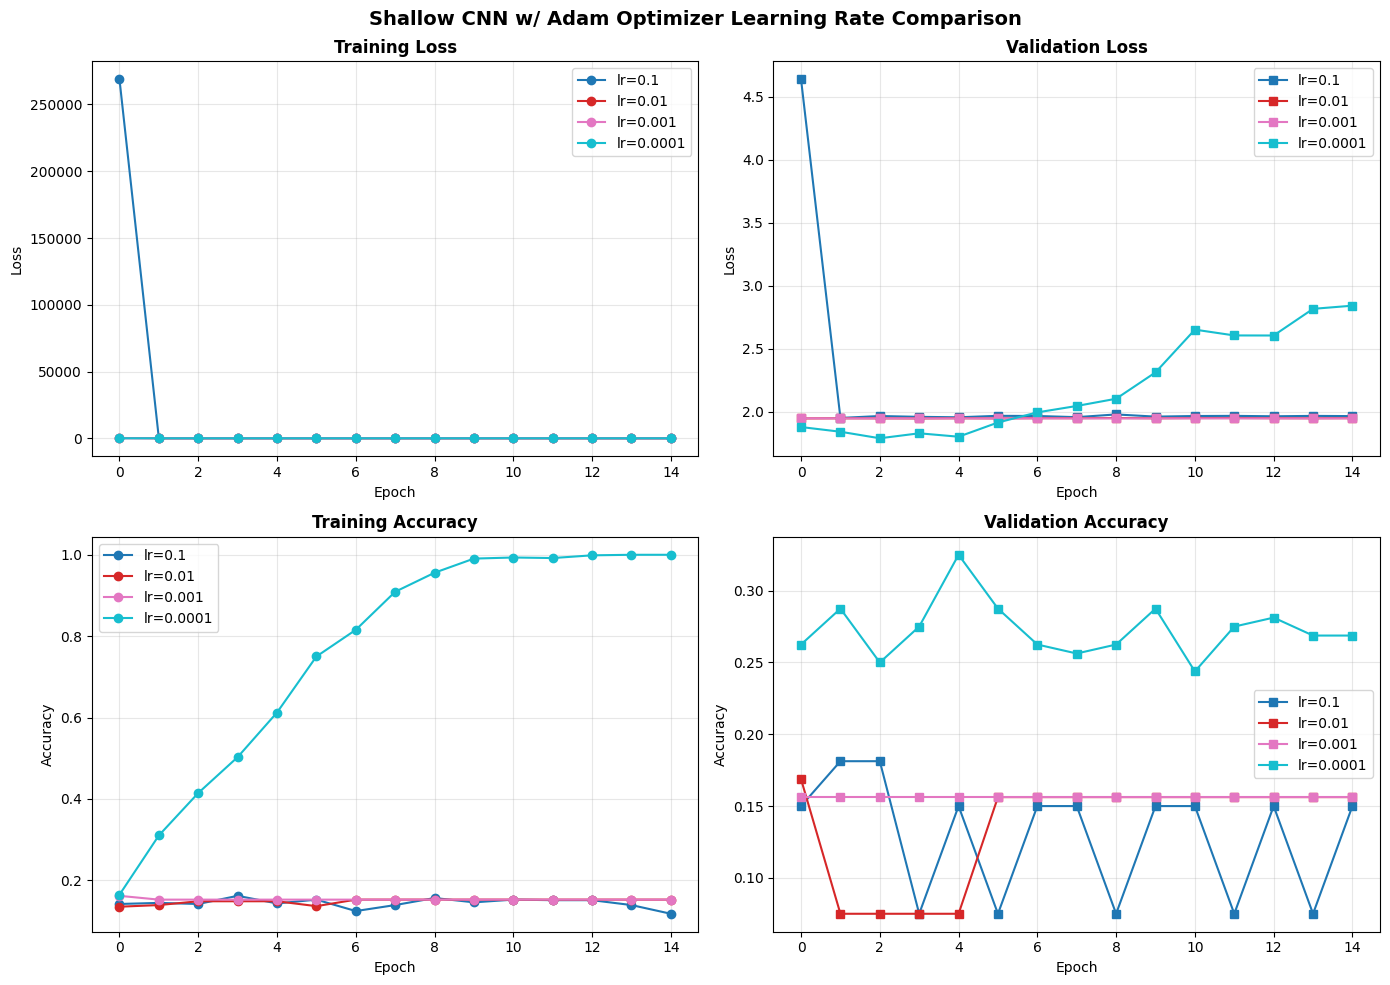

In [ ]:
# Plot learning rate comparison
plot_comparison(lr_histories, [f'lr={lr}' for lr in learning_rates],
                title="Shallow CNN w/ Adam Optimizer Learning Rate Comparison")

#### 1.5.2 Deep CNN - Learning Rate Experiments
Given that the Deep CNN with SGD optimizer was unable to learn, I will evaluate different learning rates exclusively with the Adam optimizer.

In [ ]:
# ============================================================================
# 1.5.2 DEEP CNN LEARNING RATE EXPERIMENTS
# ============================================================================

learning_rates_deep = [0.1, 0.01, 0.001, 0.0001]
lr_histories_deep = test_lr(model_type='deep', optimizer_type='adam')


Training with learning rate: 0.1
Final Valid Acc: 0.1562

Training with learning rate: 0.01
Final Valid Acc: 0.1562

Training with learning rate: 0.001
Final Valid Acc: 0.3000

Training with learning rate: 0.0001
Final Valid Acc: 0.3063

Learning rate experiments completed!


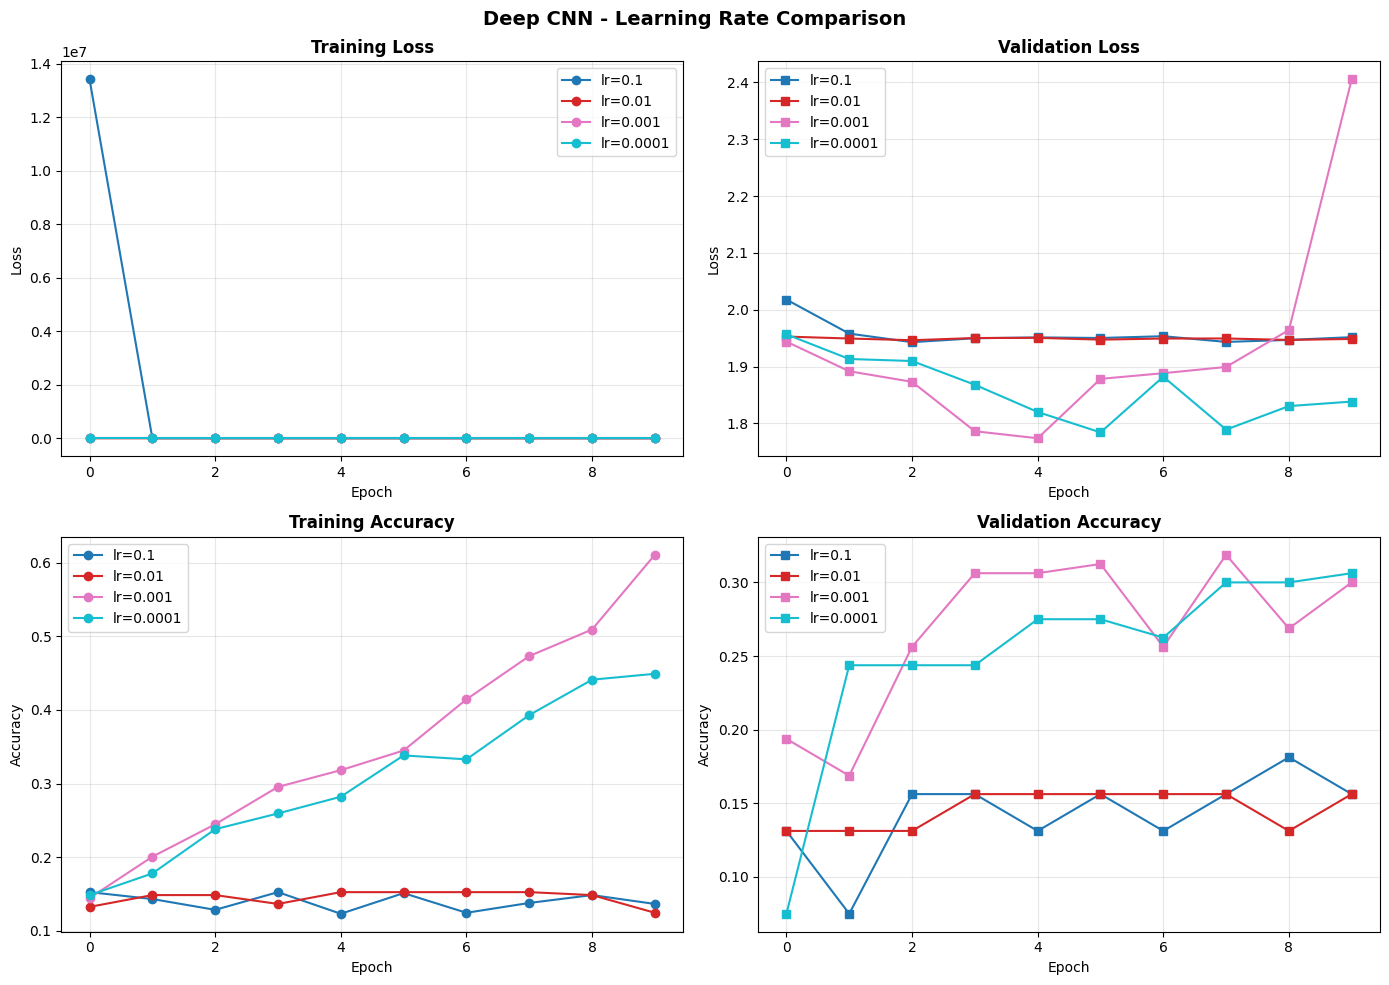

In [ ]:
# Plot learning rate comparison for Deep CNN
plot_comparison(lr_histories_deep, [f'lr={lr}' for lr in learning_rates_deep],
                title="Deep CNN - Learning Rate Comparison")

In [ ]:
def get_best_model():
  model = DeepCNN(num_classes)
  optimizer = optim.Adam(model.parameters(), lr=0.0001)
  return model, optimizer

### Best Architecture Selection

Based on the experiments, the optimal configuration is the Deep CNN with Adam optimizer at a learning rate of 0.0001. This setup achieved strong training accuracy while maintaining reasonable performance on the validation set. All subsequent experiments will use this architecture.

### 1.6 Hyperparameter Tuning: Batch Size

#### 1.6.1 Shallow CNN - Batch Size Experiments

In [ ]:
def test_batch_size(num_epochs=10):
    """
    Test different batch sizes [16, 32, 64, 128] on a CNN model.

    Args:
        model_type: 'shallow' or 'deep' (default: 'shallow')
        optimizer_type: 'sgd' or 'adam' (default: 'sgd')
        lr: Learning rate (default: 0.001)
        num_epochs: Number of training epochs (default: 10)

    Returns:
        list: Training histories for each batch size tested
    """
    batch_sizes = [16, 32, 64, 128]
    bs_histories = []

    for bs in batch_sizes:
        print(f"\n{'='*50}")
        print(f"Training with batch size: {bs}")
        print(f"{'='*50}")

        train_dl, valid_dl, test_dl = create_dataloaders(batch_size=bs)

        model, optimizer = get_best_model()

        history = train_model(model, train_dl, valid_dl, optimizer,
                              num_epochs=num_epochs, verbose=False)
        bs_histories.append(history)

        print(f"Final Valid Acc: {history['valid_acc'][-1]:.4f}")
        print(f"Training time: {history['training_time']:.2f}s")

    print("\nBatch size experiments completed!")
    return bs_histories

In [ ]:
# ============================================================================
# 1.6 BATCH SIZE EXPERIMENTS
# ============================================================================

batch_sizes = [16, 32, 64, 128]
bs_histories = test_batch_size(num_epochs=NUM_EPOCHS)



Training with batch size: 16
Final Valid Acc: 0.2938
Training time: 132.08s

Training with batch size: 32
Final Valid Acc: 0.2750
Training time: 124.59s

Training with batch size: 64
Final Valid Acc: 0.2313
Training time: 124.50s

Training with batch size: 128
Final Valid Acc: 0.2500
Training time: 121.06s

Batch size experiments completed!


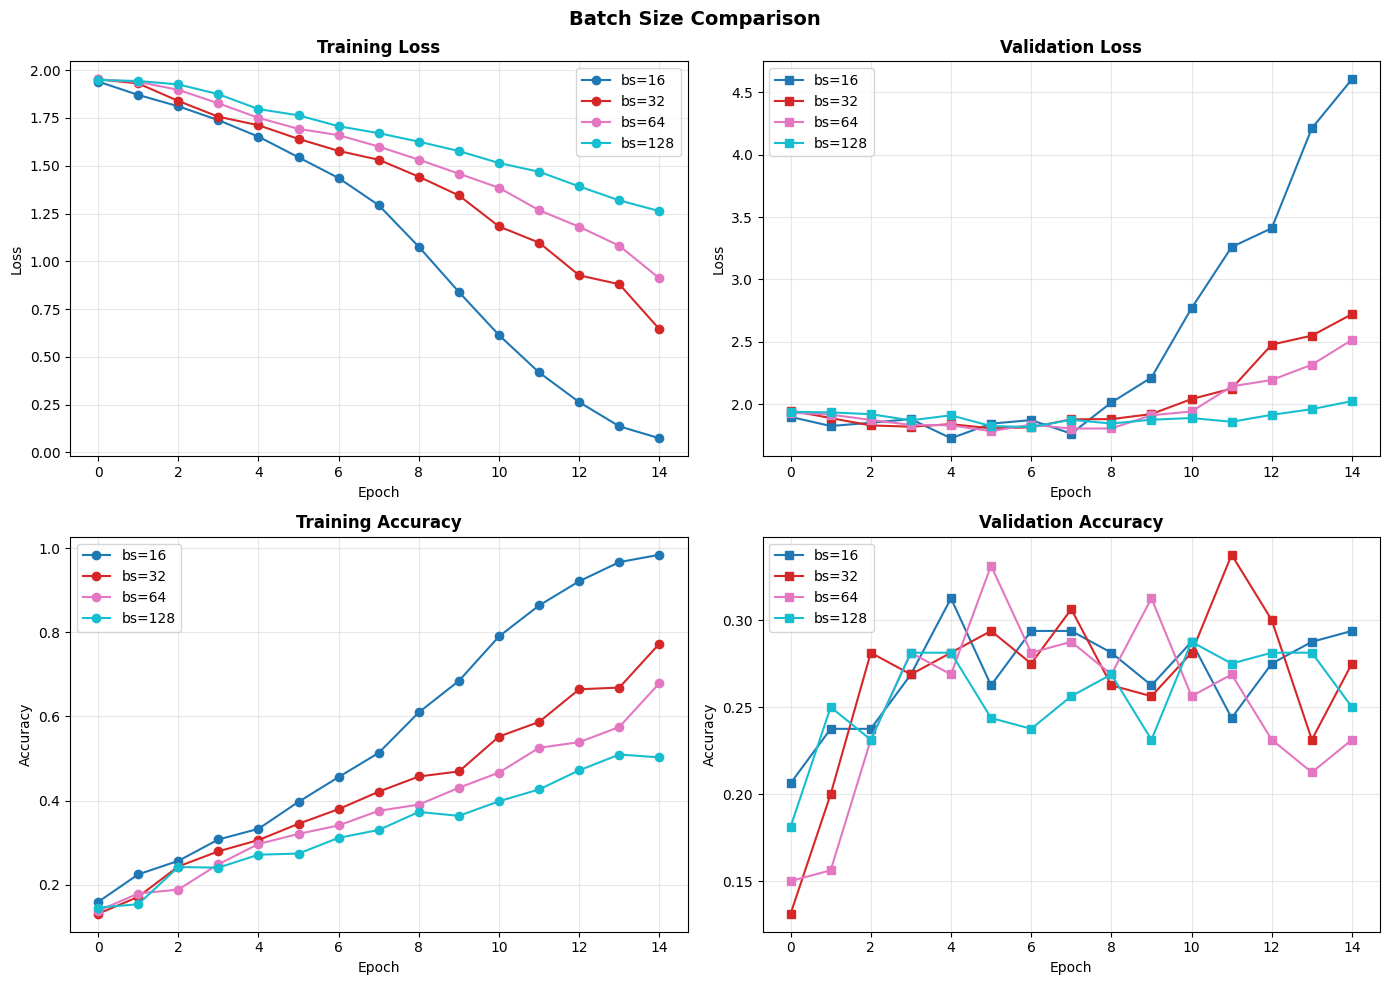

In [ ]:
# Plot batch size comparison
plot_comparison(bs_histories, [f'bs={bs}' for bs in batch_sizes],
                title="Batch Size Comparison")

In [ ]:
BEST_BATCH_SIZE = 32
train_dl, valid_dl, test_dl = create_dataloaders(batch_size=BEST_BATCH_SIZE)

---
## Step 2 — Batch Normalization

> **Goal:** Add Batch Normalization to improve training stability and convergence speed.

In [ ]:
# ============================================================================
# STEP 2: CNN WITH BATCH NORMALIZATION
# ============================================================================
class DeepCNN_BN(nn.Module):
    """
    Deep CNN with Batch Normalization
    Order: Conv → BatchNorm → ReLU → Pool
    """
    def __init__(self, num_classes=7):
        super(DeepCNN_BN, self).__init__()

        self.features = nn.Sequential(
            # Conv1 + BN
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2 + BN
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3 + BN
            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv4 + BN
            nn.Conv2d(128, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("BatchNorm architecture defined!")
print(f"DeepCNN_BN parameters: {count_parameters(DeepCNN_BN(num_classes)):,}")

BatchNorm architecture defined!
DeepCNN_BN parameters: 1,169,191


## Deep Architecture

In [ ]:
# Train models with and without BatchNorm for comparison
print("Training Deep CNN WITHOUT BatchNorm...")
deep_no_bn, optimizer = get_best_model()
history_no_bn = train_model(deep_no_bn, train_dl, valid_dl, optimizer, num_epochs=15)

Training Deep CNN WITHOUT BatchNorm...
Epoch [1/15] - Train Loss: 1.9528, Train Acc: 0.1283 - Valid Loss: 1.9573, Valid Acc: 0.1375
Epoch [2/15] - Train Loss: 1.9243, Train Acc: 0.1564 - Valid Loss: 1.8733, Valid Acc: 0.2125
Epoch [3/15] - Train Loss: 1.8093, Train Acc: 0.2714 - Valid Loss: 1.8314, Valid Acc: 0.2687
Epoch [4/15] - Train Loss: 1.7437, Train Acc: 0.2888 - Valid Loss: 1.7736, Valid Acc: 0.2875
Epoch [5/15] - Train Loss: 1.6943, Train Acc: 0.3275 - Valid Loss: 1.8066, Valid Acc: 0.2625
Epoch [6/15] - Train Loss: 1.6343, Train Acc: 0.3556 - Valid Loss: 1.7658, Valid Acc: 0.3125
Epoch [7/15] - Train Loss: 1.6082, Train Acc: 0.3489 - Valid Loss: 1.8203, Valid Acc: 0.2625
Epoch [8/15] - Train Loss: 1.5074, Train Acc: 0.4131 - Valid Loss: 1.7969, Valid Acc: 0.2313
Epoch [9/15] - Train Loss: 1.4051, Train Acc: 0.4679 - Valid Loss: 1.9190, Valid Acc: 0.2500
Epoch [10/15] - Train Loss: 1.3161, Train Acc: 0.5080 - Valid Loss: 1.9532, Valid Acc: 0.2875
Epoch [11/15] - Train Loss: 1.

In [ ]:
print("\nTraining Deep CNN WITH BatchNorm...")
deep_with_bn = DeepCNN_BN(num_classes)
_, optimizer = get_best_model()
history_with_bn = train_model(deep_with_bn, train_dl, valid_dl, optimizer, num_epochs=15)


Training Deep CNN WITH BatchNorm...
Epoch [1/15] - Train Loss: 2.0326, Train Acc: 0.1524 - Valid Loss: 1.9494, Valid Acc: 0.1313
Epoch [2/15] - Train Loss: 2.0412, Train Acc: 0.1524 - Valid Loss: 1.9713, Valid Acc: 0.1875
Epoch [3/15] - Train Loss: 2.0359, Train Acc: 0.1537 - Valid Loss: 1.9857, Valid Acc: 0.2125
Epoch [4/15] - Train Loss: 2.0397, Train Acc: 0.1618 - Valid Loss: 1.9934, Valid Acc: 0.2125
Epoch [5/15] - Train Loss: 2.0358, Train Acc: 0.1604 - Valid Loss: 1.9888, Valid Acc: 0.2000
Epoch [6/15] - Train Loss: 2.0305, Train Acc: 0.1551 - Valid Loss: 1.9880, Valid Acc: 0.2062
Epoch [7/15] - Train Loss: 2.0402, Train Acc: 0.1618 - Valid Loss: 1.9959, Valid Acc: 0.2000
Epoch [8/15] - Train Loss: 2.0380, Train Acc: 0.1471 - Valid Loss: 1.9893, Valid Acc: 0.1938
Epoch [9/15] - Train Loss: 2.0408, Train Acc: 0.1511 - Valid Loss: 1.9903, Valid Acc: 0.1938
Epoch [10/15] - Train Loss: 2.0417, Train Acc: 0.1564 - Valid Loss: 1.9963, Valid Acc: 0.2000
Epoch [11/15] - Train Loss: 2.04

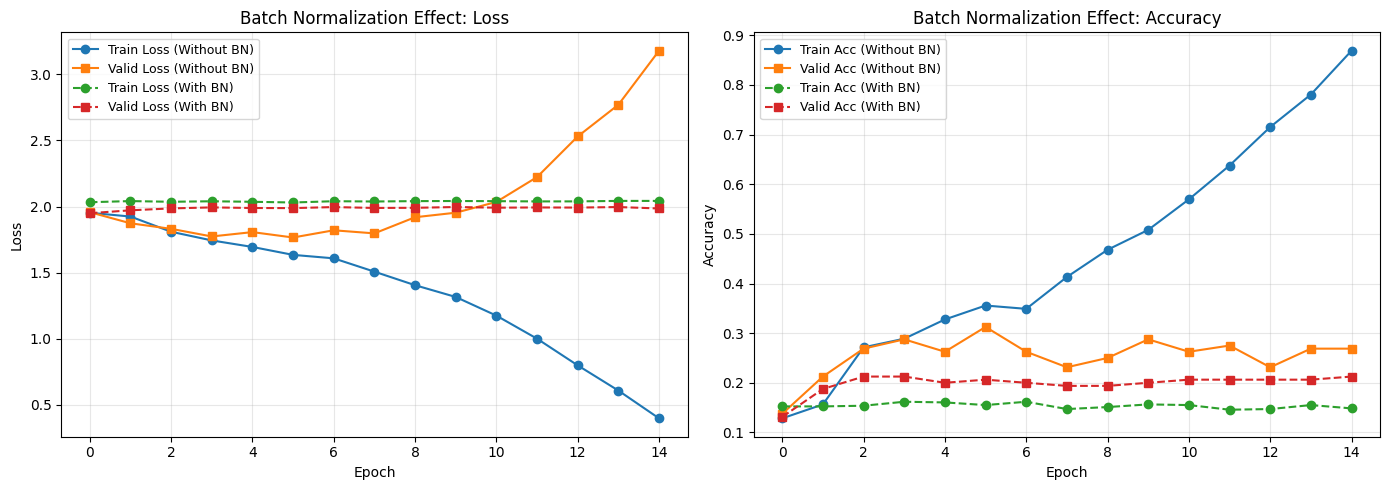

In [ ]:
# Plot BatchNorm comparison
plot_compare(history_no_bn, history_with_bn,
             label1='Without BN', label2='With BN',
             title_prefix='Batch Normalization Effect')

Batch normalization did not improve the already best model.

---
##  Step 3 — Regularization

> **Goal:** Combat overfitting using Dropout, Weight Decay, and Data Augmentation.

In [ ]:
# ============================================================================
# STEP 3: CNN WITH REGULARIZATION
# ============================================================================
class DeepCNN_Regularized(nn.Module):
    """
    Deep CNN with BatchNorm and Dropout
    """
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(DeepCNN_Regularized, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate * 0.5),

            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=dropout_rate * 0.5),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Regularized architectures defined!")

Regularized architectures defined!


### 3.1 Dropout Rate Experiments

In [ ]:
# ============================================================================
# 3.1 DROPOUT RATE EXPERIMENTS
# ============================================================================

dropout_rates = [0.25, 0.5, 0.7]
dropout_histories = []

for dropout in dropout_rates:
    print(f"\n{'='*50}")
    print(f"Training with dropout rate: {dropout}")
    print(f"{'='*50}")

    model = DeepCNN_Regularized(num_classes, dropout_rate=dropout)
    _,optimizer = get_best_model()
    history = train_model(model, train_dl, valid_dl, optimizer,
                          num_epochs=15, verbose=False)
    dropout_histories.append(history)

    print(f"Final Train Acc: {history['train_acc'][-1]:.4f}")
    print(f"Final Valid Acc: {history['valid_acc'][-1]:.4f}")
    print(f"Overfitting Gap: {history['train_acc'][-1] - history['valid_acc'][-1]:.4f}")


Training with dropout rate: 0.25
Final Train Acc: 0.1257
Final Valid Acc: 0.1500
Overfitting Gap: -0.0243

Training with dropout rate: 0.5
Final Train Acc: 0.1524
Final Valid Acc: 0.1313
Overfitting Gap: 0.0212

Training with dropout rate: 0.7
Final Train Acc: 0.1537
Final Valid Acc: 0.1250
Overfitting Gap: 0.0287


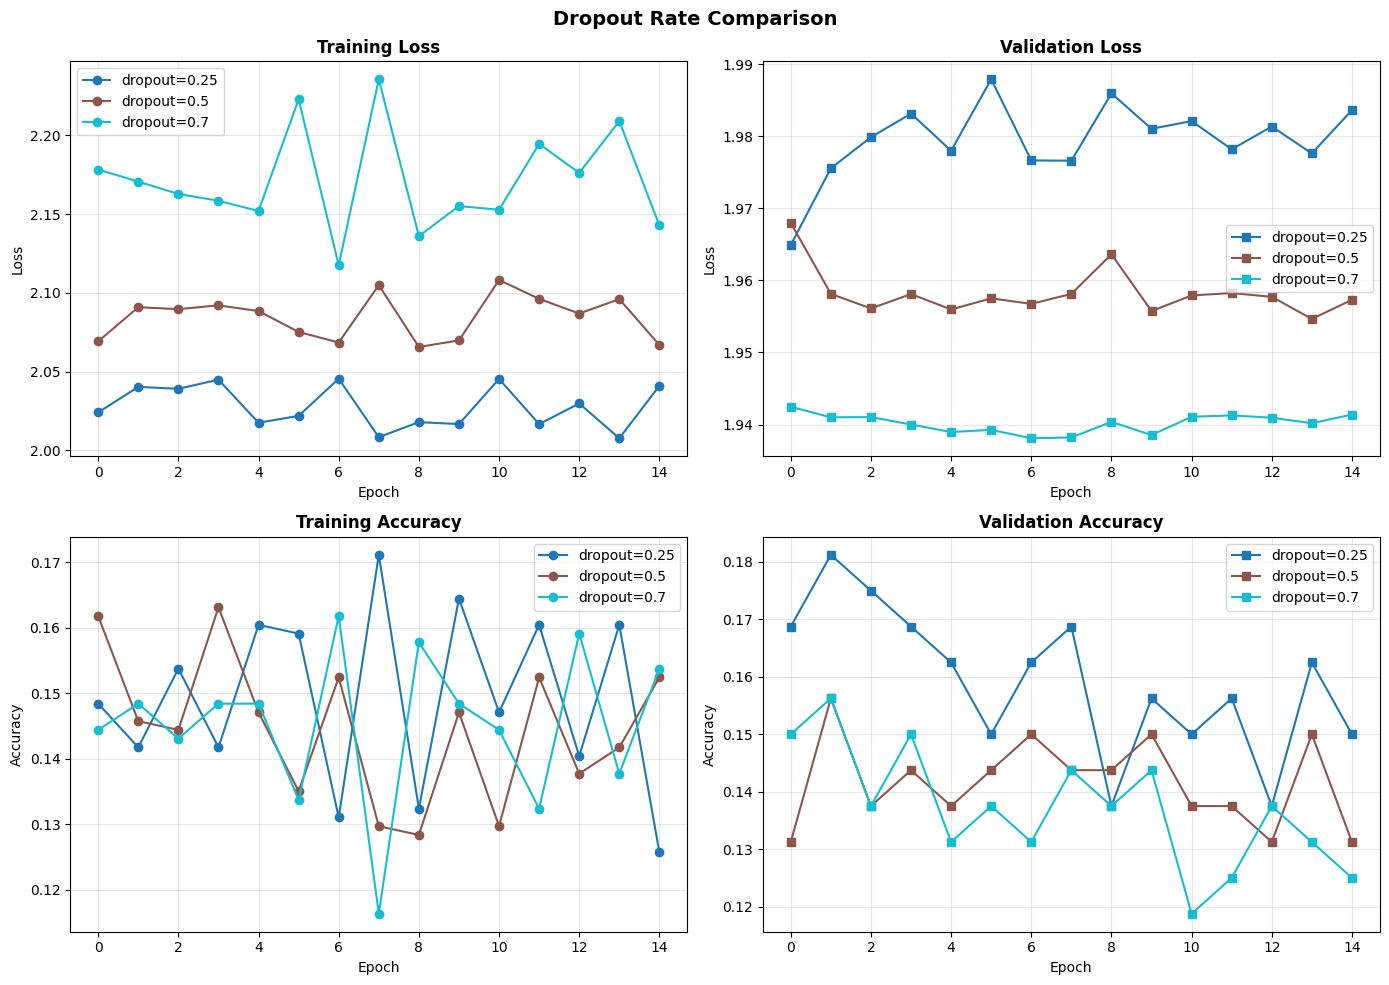

In [ ]:
# Plot dropout comparison
plot_comparison(dropout_histories, [f'dropout={d}' for d in dropout_rates],
                title="Dropout Rate Comparison")

### Neuron Drop Out Results

Although Neuron Drop Out largely eliminated overfitting, it resulted in extremely low accuracy on both training and test sets - in some cases performing worse than random guessing (1/7 = 0.142).
The best model remains Deep CNN, Adam optimizer with 0.0001 lr and 32 batch size.

### 3.2 Weight Decay (L2 Regularization) Experiments

In [ ]:
# ============================================================================
# 3.2 WEIGHT DECAY EXPERIMENTS
# ============================================================================

weight_decays = [1e-5, 1e-4, 1e-3, 1e-2]
wd_histories = []

for wd in weight_decays:
    print(f"\n{'='*50}")
    print(f"Training with weight decay: {wd}")
    print(f"{'='*50}")

    model, _ = get_best_model()
    optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=wd)
    history = train_model(model, train_dl, valid_dl, optimizer,
                          num_epochs=15, verbose=False)
    wd_histories.append(history)

    print(f"Final Train Acc: {history['train_acc'][-1]:.4f}")
    print(f"Final Valid Acc: {history['valid_acc'][-1]:.4f}")


Training with weight decay: 1e-05
Final Train Acc: 0.8944
Final Valid Acc: 0.2750

Training with weight decay: 0.0001
Final Train Acc: 0.8730
Final Valid Acc: 0.2750

Training with weight decay: 0.001
Final Train Acc: 0.9799
Final Valid Acc: 0.2500

Training with weight decay: 0.01
Final Train Acc: 0.7527
Final Valid Acc: 0.2250


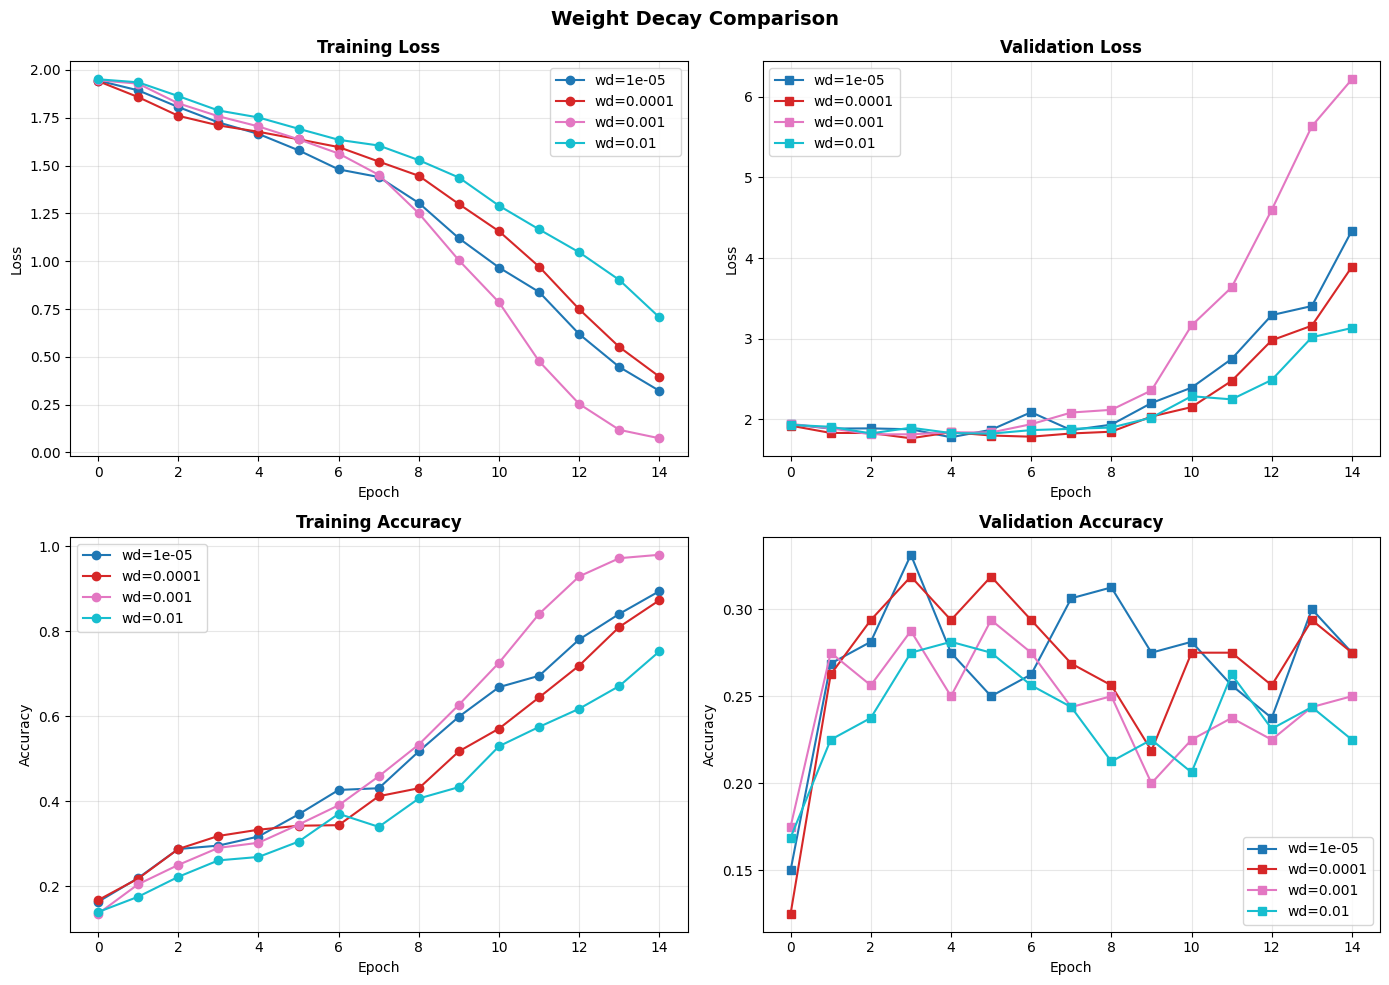

In [ ]:
# Plot weight decay comparison
plot_comparison(wd_histories, [f'wd={wd}' for wd in weight_decays],
                title="Weight Decay Comparison")

### Weight Decay Results

Weight Dacay similarly to Neuron Drop Out largely eliminated overfitting, but it did not show a significat gain in accuracy or narrowing the overfitting gap.
The best model remains Deep CNN, Adam optimizer with 0.0001 lr and 32 batch size.

---
# PART 2 — Transfer Learning
> **Goal:** Pretrain my own CNN on CIFAR-10, then fine-tune on your dataset.

## Step 4 — Pretraining on CIFAR-10


In [ ]:
# ============================================================================
# STEP 4: LOAD AND PREPARE CIFAR-10
# ============================================================================

# CIFAR-10 transforms (resized to 224x224)
cifar_transform_train = transforms.Compose([
    transforms.Resize(224),  # Resize to 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

cifar_transform_test = transforms.Compose([
    transforms.Resize(224),  # Resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Download CIFAR-10
cifar_train = datasets.CIFAR10(root='./CIFAR10', train=True, download=True, transform=cifar_transform_train)
cifar_test = datasets.CIFAR10(root='./CIFAR10', train=False, download=True, transform=cifar_transform_test)

# Split train into train/val
cifar_train_size = int(0.9 * len(cifar_train))
cifar_val_size = len(cifar_train) - cifar_train_size
cifar_train_ds, cifar_val_ds = random_split(cifar_train, [cifar_train_size, cifar_val_size],
                                             generator=torch.Generator().manual_seed(42))

# Create DataLoaders
cifar_train_loader = DataLoader(cifar_train_ds, batch_size=128, shuffle=True)
cifar_val_loader = DataLoader(cifar_val_ds, batch_size=128, shuffle=False)
cifar_test_loader = DataLoader(cifar_test, batch_size=128, shuffle=False)

cifr_num_classes = len(cifar_train.classes)

print(f"CIFAR-10 Dataset:")
print(f"  Training: {len(cifar_train_ds)}")
print(f"  Validation: {len(cifar_val_ds)}")
print(f"  Test: {len(cifar_test)}")
print(f"  Classes: {cifar_train.classes}")

CIFAR-10 Dataset:
  Training: 45000
  Validation: 5000
  Test: 10000
  Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
class DeepCNN_CIFR(nn.Module):
    """
    Architecture B: Deep CNN
    4 Conv layers + 3 FC layers
    Input: 224x224 RGB images → Output: num_classes
    """
    def __init__(self, num_classes=10):
        super(DeepCNN_CIFR, self).__init__()

        self.features = nn.Sequential(
            # Conv1: 3 → 32 channels
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 → 112

            # Conv2: 32 → 64 channels
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 → 56

            # Conv3: 64 → 128 channels
            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 → 28

            # Conv4: 128 → 32 channels
            nn.Conv2d(128, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 → 14
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
# ============================================================================
# PRETRAIN ON CIFAR-10
# ============================================================================

print("Pretraining CNN on CIFAR-10...")


pretrained_model = DeepCNN(cifr_num_classes)
optimizer = optim.Adam(pretrained_model.parameters(), lr=0.0001)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

history_cifar = train_model(pretrained_model, cifar_train_loader, cifar_val_loader,
                            optimizer, num_epochs=4)

# Evaluate on CIFAR-10 test set
cifar_test_acc, _, _ = evaluate_model(pretrained_model, cifar_test_loader)
print(f"\n🎯 CIFAR-10 Test Accuracy: {cifar_test_acc:.4f}")

# Save pretrained weights
torch.save(pretrained_model.state_dict(), 'pretrained_cifar10.pth')
print("Pretrained weights saved to 'pretrained_cifar10.pth'")

Pretraining CNN on CIFAR-10...
Epoch [1/4] - Train Loss: 1.7758, Train Acc: 0.3668 - Valid Loss: 1.4786, Valid Acc: 0.4742
Epoch [2/4] - Train Loss: 1.3930, Train Acc: 0.5047 - Valid Loss: 1.3207, Valid Acc: 0.5258
Epoch [3/4] - Train Loss: 1.2708, Train Acc: 0.5489 - Valid Loss: 1.2284, Valid Acc: 0.5686
Epoch [4/4] - Train Loss: 1.1748, Train Acc: 0.5842 - Valid Loss: 1.1605, Valid Acc: 0.5886

Total training time: 830.37s

🎯 CIFAR-10 Test Accuracy: 0.5900
Pretrained weights saved to 'pretrained_cifar10.pth'


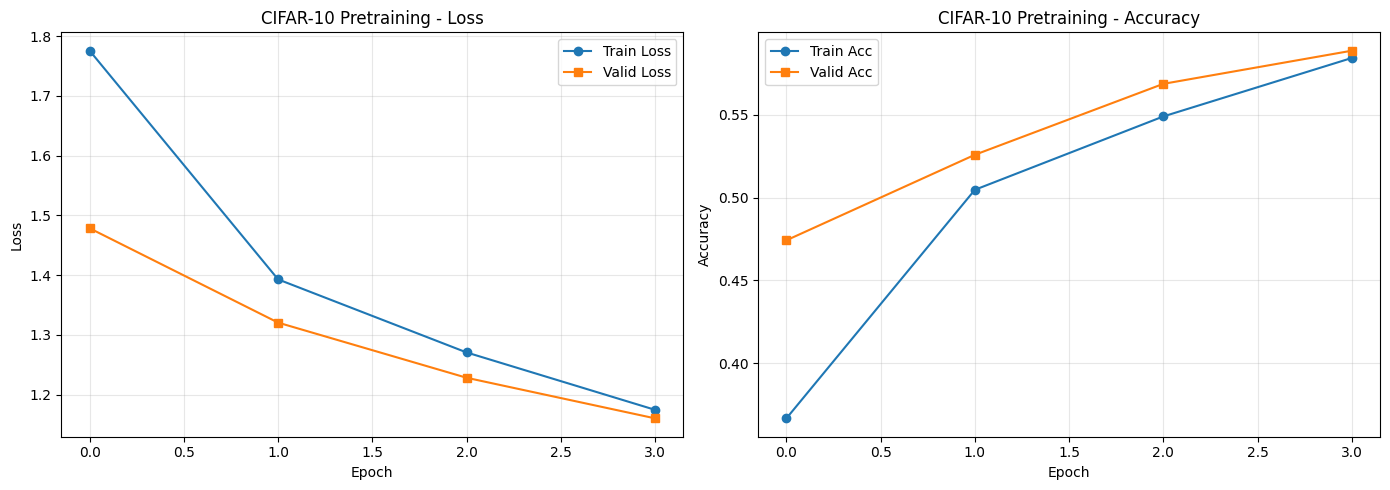

In [ ]:
# Plot CIFAR-10 pretraining results
plot_training_history(history_cifar, title="CIFAR-10 Pretraining")

## Step 5 - Fine-Tuning on my dataset

In [ ]:
# ============================================================================
# LOAD PRETRAINED WEIGHTS AND TRANSFER
# ============================================================================

def transfer_weights(pretrained_model, target_model):
    """Transfer weights from pretrained model to target model (feature layers only)."""
    pretrained_dict = pretrained_model.state_dict()
    target_dict = target_model.state_dict()

    # Filter out classifier weights, transfer only feature extractor weights
    transfer_dict = {}
    for key in pretrained_dict:
        if key in target_dict and 'classifier' not in key:
            if pretrained_dict[key].shape == target_dict[key].shape:
                transfer_dict[key] = pretrained_dict[key]
                print(f"  Transferred: {key}")

    target_dict.update(transfer_dict)
    target_model.load_state_dict(target_dict)
    return target_model

# Create transfer model and load pretrained weights
transfer_model = DeepCNN(7)
print("Transferring feature extractor weights from CIFAR-10 model...")
transfer_model = transfer_weights(pretrained_model, transfer_model)
print(f"\nTransferred {len([k for k in pretrained_model.state_dict() if 'classifier' not in k])} layers")

Transferring feature extractor weights from CIFAR-10 model...
  Transferred: features.0.weight
  Transferred: features.0.bias
  Transferred: features.3.weight
  Transferred: features.3.bias
  Transferred: features.6.weight
  Transferred: features.6.bias
  Transferred: features.9.weight
  Transferred: features.9.bias

Transferred 8 layers


### 5.1 Fine-tuning Experiments

In [ ]:
# ============================================================================
# EXPERIMENT 1: Fine-tune all layers
# ============================================================================

print("Experiment 1: Fine-tune ALL layers...")

model_finetune_all = DeepCNN(7)
model_finetune_all = transfer_weights(pretrained_model, model_finetune_all)

# All layers trainable
for param in model_finetune_all.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model_finetune_all.parameters(), lr=0.0001)
history_finetune_all = train_model(model_finetune_all, train_dl, valid_dl,
                                    optimizer, num_epochs=15)

Experiment 1: Fine-tune ALL layers...
  Transferred: features.0.weight
  Transferred: features.0.bias
  Transferred: features.3.weight
  Transferred: features.3.bias
  Transferred: features.6.weight
  Transferred: features.6.bias
  Transferred: features.9.weight
  Transferred: features.9.bias
Epoch [1/15] - Train Loss: 1.9478, Train Acc: 0.1765 - Valid Loss: 1.8761, Valid Acc: 0.2562
Epoch [2/15] - Train Loss: 1.6762, Train Acc: 0.3529 - Valid Loss: 1.8447, Valid Acc: 0.2750
Epoch [3/15] - Train Loss: 1.3413, Train Acc: 0.5241 - Valid Loss: 1.9035, Valid Acc: 0.2750
Epoch [4/15] - Train Loss: 0.9512, Train Acc: 0.6845 - Valid Loss: 2.1420, Valid Acc: 0.2875
Epoch [5/15] - Train Loss: 0.6252, Train Acc: 0.7901 - Valid Loss: 2.5402, Valid Acc: 0.3563
Epoch [6/15] - Train Loss: 0.3525, Train Acc: 0.9118 - Valid Loss: 2.8140, Valid Acc: 0.3000
Epoch [7/15] - Train Loss: 0.2105, Train Acc: 0.9519 - Valid Loss: 3.2715, Valid Acc: 0.3438
Epoch [8/15] - Train Loss: 0.0937, Train Acc: 0.9893 - 

In [ ]:
# ============================================================================
# EXPERIMENT 2: Freeze early layers, fine-tune later layers
# ============================================================================

print("\nExperiment 2: Freeze early conv layers, fine-tune later layers...")

model_finetune_partial = DeepCNN(7)
model_finetune_partial = transfer_weights(pretrained_model, model_finetune_partial)

# Freeze first 2 conv blocks (features[0:8])
for i, (name, param) in enumerate(model_finetune_partial.features.named_parameters()):
    if i < 8:  # First 2 conv blocks
        param.requires_grad = False
        print(f"  Frozen: features.{name}")

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_finetune_partial.parameters()), lr=0.0001)
history_finetune_partial = train_model(model_finetune_partial, train_dl, valid_dl,
                                        optimizer, num_epochs=15)


Experiment 2: Freeze early conv layers, fine-tune later layers...
  Transferred: features.0.weight
  Transferred: features.0.bias
  Transferred: features.3.weight
  Transferred: features.3.bias
  Transferred: features.6.weight
  Transferred: features.6.bias
  Transferred: features.9.weight
  Transferred: features.9.bias
  Frozen: features.0.weight
  Frozen: features.0.bias
  Frozen: features.3.weight
  Frozen: features.3.bias
  Frozen: features.6.weight
  Frozen: features.6.bias
  Frozen: features.9.weight
  Frozen: features.9.bias
Epoch [1/15] - Train Loss: 1.9301, Train Acc: 0.1912 - Valid Loss: 1.8141, Valid Acc: 0.3125
Epoch [2/15] - Train Loss: 1.5784, Train Acc: 0.4158 - Valid Loss: 1.8021, Valid Acc: 0.2875
Epoch [3/15] - Train Loss: 1.3280, Train Acc: 0.5388 - Valid Loss: 1.7510, Valid Acc: 0.3750
Epoch [4/15] - Train Loss: 1.1435, Train Acc: 0.5856 - Valid Loss: 1.7326, Valid Acc: 0.3438
Epoch [5/15] - Train Loss: 0.9435, Train Acc: 0.7126 - Valid Loss: 1.7470, Valid Acc: 0.3

In [ ]:
# ============================================================================
# EXPERIMENT 3: Train from scratch (for comparison)
# ============================================================================

print("\nExperiment 3: Train from scratch (no pretraining)...")

model_from_scratch = DeepCNN(7)
# No weight transfer - random initialization

optimizer = optim.Adam(model_from_scratch.parameters(), lr=0.0001)
history_from_scratch = train_model(model_from_scratch, train_dl, valid_dl,
                                    optimizer, num_epochs=15)


Experiment 3: Train from scratch (no pretraining)...
Epoch [1/15] - Train Loss: 1.9482, Train Acc: 0.1297 - Valid Loss: 1.9334, Valid Acc: 0.1500
Epoch [2/15] - Train Loss: 1.8821, Train Acc: 0.2099 - Valid Loss: 1.8620, Valid Acc: 0.2625
Epoch [3/15] - Train Loss: 1.7996, Train Acc: 0.2607 - Valid Loss: 1.8509, Valid Acc: 0.2125
Epoch [4/15] - Train Loss: 1.7281, Train Acc: 0.2741 - Valid Loss: 1.7633, Valid Acc: 0.2500
Epoch [5/15] - Train Loss: 1.6703, Train Acc: 0.3289 - Valid Loss: 1.8214, Valid Acc: 0.3063
Epoch [6/15] - Train Loss: 1.6388, Train Acc: 0.3369 - Valid Loss: 1.8222, Valid Acc: 0.3063
Epoch [7/15] - Train Loss: 1.5936, Train Acc: 0.3757 - Valid Loss: 1.8529, Valid Acc: 0.2687
Epoch [8/15] - Train Loss: 1.5095, Train Acc: 0.4345 - Valid Loss: 1.8106, Valid Acc: 0.2562
Epoch [9/15] - Train Loss: 1.4518, Train Acc: 0.4519 - Valid Loss: 1.8510, Valid Acc: 0.2437
Epoch [10/15] - Train Loss: 1.3192, Train Acc: 0.4920 - Valid Loss: 2.0715, Valid Acc: 0.2562
Epoch [11/15] -

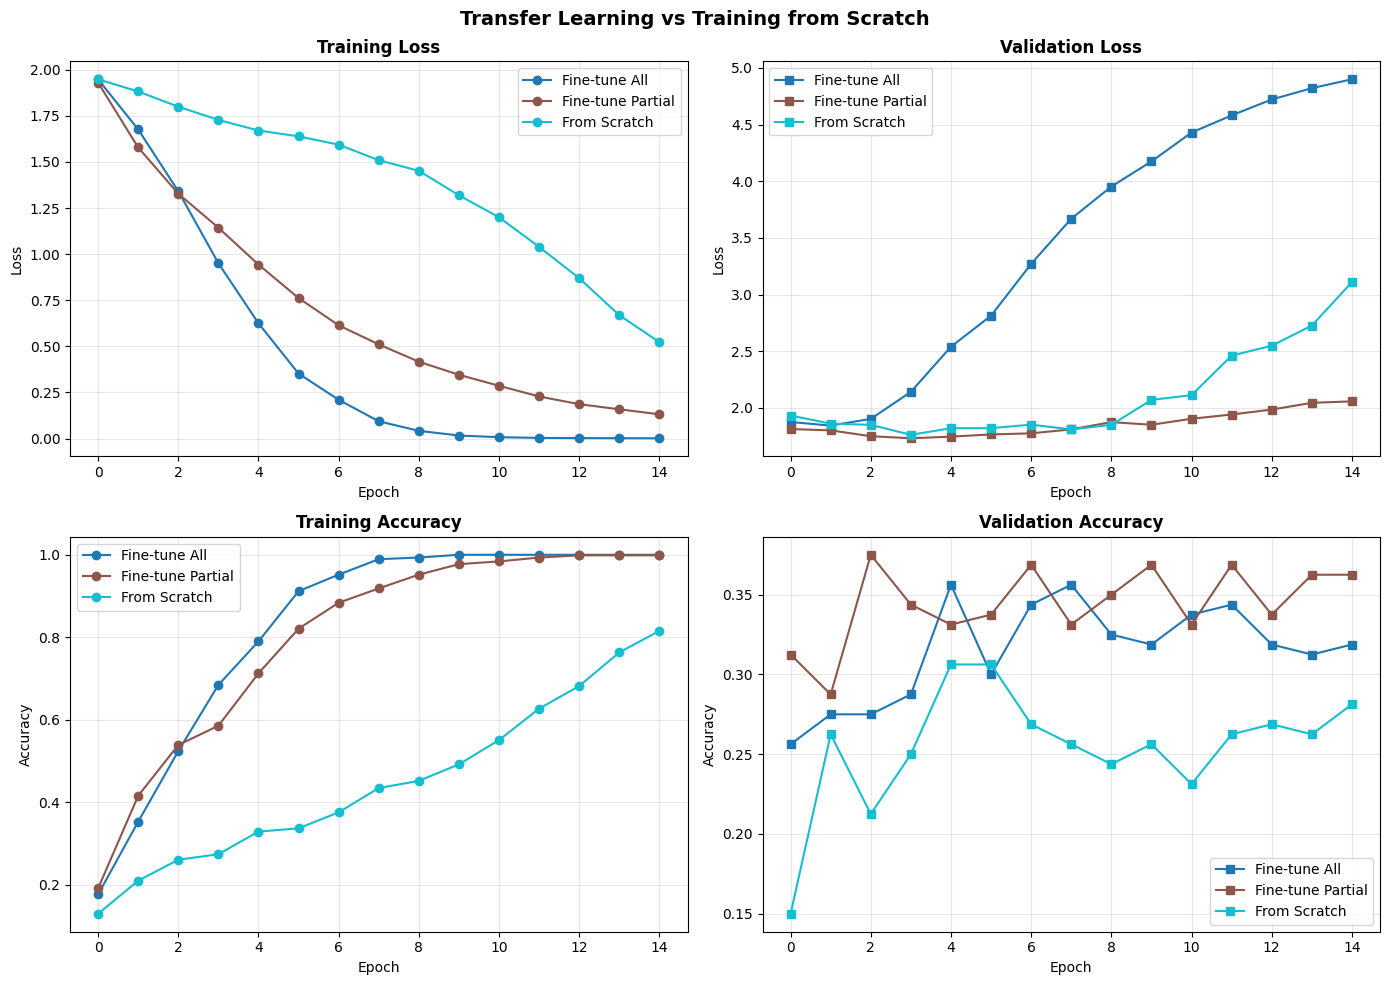


TEST SET EVALUATION
Fine-tune All Layers:    0.3106
Fine-tune Partial:       0.3478
From Scratch:            0.2547


In [ ]:
# ============================================================================
# COMPARE TRANSFER LEARNING VS FROM SCRATCH
# ============================================================================

# Plot comparison
plot_comparison(
    [history_finetune_all, history_finetune_partial, history_from_scratch],
    ['Fine-tune All', 'Fine-tune Partial', 'From Scratch'],
    title="Transfer Learning vs Training from Scratch"
)

# Evaluate all models on test set
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

test_acc_all, _, _ = evaluate_model(model_finetune_all, test_dl)
test_acc_partial, _, _ = evaluate_model(model_finetune_partial, test_dl)
test_acc_scratch, _, _ = evaluate_model(model_from_scratch, test_dl)

print(f"Fine-tune All Layers:    {test_acc_all:.4f}")
print(f"Fine-tune Partial:       {test_acc_partial:.4f}")
print(f"From Scratch:            {test_acc_scratch:.4f}")

---
# PART 3 — Transfer Learning with ResNet50

> **Goal:** Leverage ImageNet-pretrained ResNet50 for maximum performance.

## Step 6 — Adapting ResNet50

In [ ]:
# ============================================================================
# STEP 6: LOAD AND ADAPT RESNET50
# ============================================================================

def create_resnet50(num_classes, freeze_features=True):
    """
    Create ResNet50 model with modified final layer.

    Args:
        num_classes: Number of output classes
        freeze_features: If True, freeze all feature layers
    """
    # Load pretrained ResNet50
    resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # Freeze feature layers if specified
    if freeze_features:
        for param in resnet.parameters():
            param.requires_grad = False

    # Replace final fully connected layer
    num_features = resnet.fc.in_features  # 2048
    resnet.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    return resnet

# Create model and explore architecture
resnet50_model = create_resnet50(7, freeze_features=True)
print("ResNet50 Architecture (modified):")
print(f"Total parameters: {count_parameters(resnet50_model):,}")
print(f"Trainable parameters: {sum(p.numel() for p in resnet50_model.parameters() if p.requires_grad):,}")

ResNet50 Architecture (modified):
Total parameters: 1,052,679
Trainable parameters: 1,052,679


## 🎓 Step 7 — Training & Fine-Tuning ResNet50

In [ ]:
# ============================================================================
# EXPERIMENT 1: Feature Extraction Only (freeze all except FC)
# ============================================================================

print("ResNet50 Experiment 1: Feature Extraction (frozen features)...")

resnet_frozen = create_resnet50(num_classes, freeze_features=True)
optimizer = optim.Adam(resnet_frozen.fc.parameters(), lr=1e-3)

history_resnet_frozen = train_model(resnet_frozen, train_dl, valid_dl,
                                     optimizer, num_epochs=10)

ResNet50 Experiment 1: Feature Extraction (frozen features)...
Epoch [1/10] - Train Loss: 1.1204, Train Acc: 0.6832 - Valid Loss: 0.2714, Valid Acc: 0.9563
Epoch [2/10] - Train Loss: 0.2377, Train Acc: 0.9332 - Valid Loss: 0.1765, Valid Acc: 0.9375
Epoch [3/10] - Train Loss: 0.1394, Train Acc: 0.9599 - Valid Loss: 0.1423, Valid Acc: 0.9437
Epoch [4/10] - Train Loss: 0.0992, Train Acc: 0.9719 - Valid Loss: 0.1213, Valid Acc: 0.9563
Epoch [5/10] - Train Loss: 0.0645, Train Acc: 0.9840 - Valid Loss: 0.1346, Valid Acc: 0.9563
Epoch [6/10] - Train Loss: 0.0395, Train Acc: 0.9960 - Valid Loss: 0.1444, Valid Acc: 0.9500
Epoch [7/10] - Train Loss: 0.0426, Train Acc: 0.9920 - Valid Loss: 0.1432, Valid Acc: 0.9437
Epoch [8/10] - Train Loss: 0.0317, Train Acc: 0.9960 - Valid Loss: 0.1528, Valid Acc: 0.9625
Epoch [9/10] - Train Loss: 0.0282, Train Acc: 0.9973 - Valid Loss: 0.1391, Valid Acc: 0.9563
Epoch [10/10] - Train Loss: 0.0243, Train Acc: 0.9960 - Valid Loss: 0.1325, Valid Acc: 0.9375

Total

In [ ]:
# ============================================================================
# EXPERIMENT 2: Partial Fine-tuning (unfreeze layer4)
# ============================================================================

print("\nResNet50 Experiment 2: Partial Fine-tuning (unfreeze layer4)...")

resnet_partial = create_resnet50(7, freeze_features=True)

# Unfreeze layer4
for param in resnet_partial.layer4.parameters():
    param.requires_grad = True

print(f"Trainable parameters after unfreezing layer4: {sum(p.numel() for p in resnet_partial.parameters() if p.requires_grad):,}")

optimizer = optim.Adam([
    {'params': resnet_partial.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet_partial.fc.parameters(), 'lr': 1e-3}
])

history_resnet_partial = train_model(resnet_partial, train_dl, valid_dl,
                                      optimizer, num_epochs=15)


ResNet50 Experiment 2: Partial Fine-tuning (unfreeze layer4)...
Trainable parameters after unfreezing layer4: 16,017,415
Epoch [1/15] - Train Loss: 0.8593, Train Acc: 0.7326 - Valid Loss: 0.1580, Valid Acc: 0.9563
Epoch [2/15] - Train Loss: 0.1177, Train Acc: 0.9612 - Valid Loss: 0.1254, Valid Acc: 0.9563
Epoch [3/15] - Train Loss: 0.0214, Train Acc: 0.9973 - Valid Loss: 0.0717, Valid Acc: 0.9688
Epoch [4/15] - Train Loss: 0.0147, Train Acc: 0.9947 - Valid Loss: 0.0644, Valid Acc: 0.9688
Epoch [5/15] - Train Loss: 0.0238, Train Acc: 0.9920 - Valid Loss: 0.1156, Valid Acc: 0.9625
Epoch [6/15] - Train Loss: 0.0172, Train Acc: 0.9947 - Valid Loss: 0.0976, Valid Acc: 0.9688
Epoch [7/15] - Train Loss: 0.0394, Train Acc: 0.9853 - Valid Loss: 0.0916, Valid Acc: 0.9812
Epoch [8/15] - Train Loss: 0.0296, Train Acc: 0.9933 - Valid Loss: 0.0788, Valid Acc: 0.9750
Epoch [9/15] - Train Loss: 0.0162, Train Acc: 0.9960 - Valid Loss: 0.1071, Valid Acc: 0.9750
Epoch [10/15] - Train Loss: 0.0094, Train

In [ ]:
# ============================================================================
# EXPERIMENT 3: Full Fine-tuning (unfreeze all)
# ============================================================================

print("\nResNet50 Experiment 3: Full Fine-tuning...")

resnet_full = create_resnet50(7, freeze_features=False)

# Differential learning rates
optimizer = optim.Adam([
    {'params': resnet_full.conv1.parameters(), 'lr': 1e-5},
    {'params': resnet_full.bn1.parameters(), 'lr': 1e-5},
    {'params': resnet_full.layer1.parameters(), 'lr': 1e-5},
    {'params': resnet_full.layer2.parameters(), 'lr': 5e-5},
    {'params': resnet_full.layer3.parameters(), 'lr': 1e-4},
    {'params': resnet_full.layer4.parameters(), 'lr': 5e-4},
    {'params': resnet_full.fc.parameters(), 'lr': 1e-3}
])

history_resnet_full = train_model(resnet_full, train_dl, valid_dl,
                                   optimizer, num_epochs=15)


ResNet50 Experiment 3: Full Fine-tuning...
Epoch [1/15] - Train Loss: 0.7113, Train Acc: 0.7781 - Valid Loss: 0.3703, Valid Acc: 0.9187
Epoch [2/15] - Train Loss: 0.1493, Train Acc: 0.9545 - Valid Loss: 0.2281, Valid Acc: 0.9375
Epoch [3/15] - Train Loss: 0.0920, Train Acc: 0.9733 - Valid Loss: 0.2323, Valid Acc: 0.9437
Epoch [4/15] - Train Loss: 0.1104, Train Acc: 0.9746 - Valid Loss: 0.2077, Valid Acc: 0.9187
Epoch [5/15] - Train Loss: 0.0594, Train Acc: 0.9893 - Valid Loss: 0.2307, Valid Acc: 0.9500
Epoch [6/15] - Train Loss: 0.1024, Train Acc: 0.9799 - Valid Loss: 0.3163, Valid Acc: 0.9062
Epoch [7/15] - Train Loss: 0.0292, Train Acc: 0.9920 - Valid Loss: 0.2459, Valid Acc: 0.9250
Epoch [8/15] - Train Loss: 0.0404, Train Acc: 0.9906 - Valid Loss: 0.2071, Valid Acc: 0.9375
Epoch [9/15] - Train Loss: 0.0172, Train Acc: 0.9933 - Valid Loss: 0.3147, Valid Acc: 0.9187
Epoch [10/15] - Train Loss: 0.0117, Train Acc: 0.9973 - Valid Loss: 0.4152, Valid Acc: 0.8875
Epoch [11/15] - Train Los

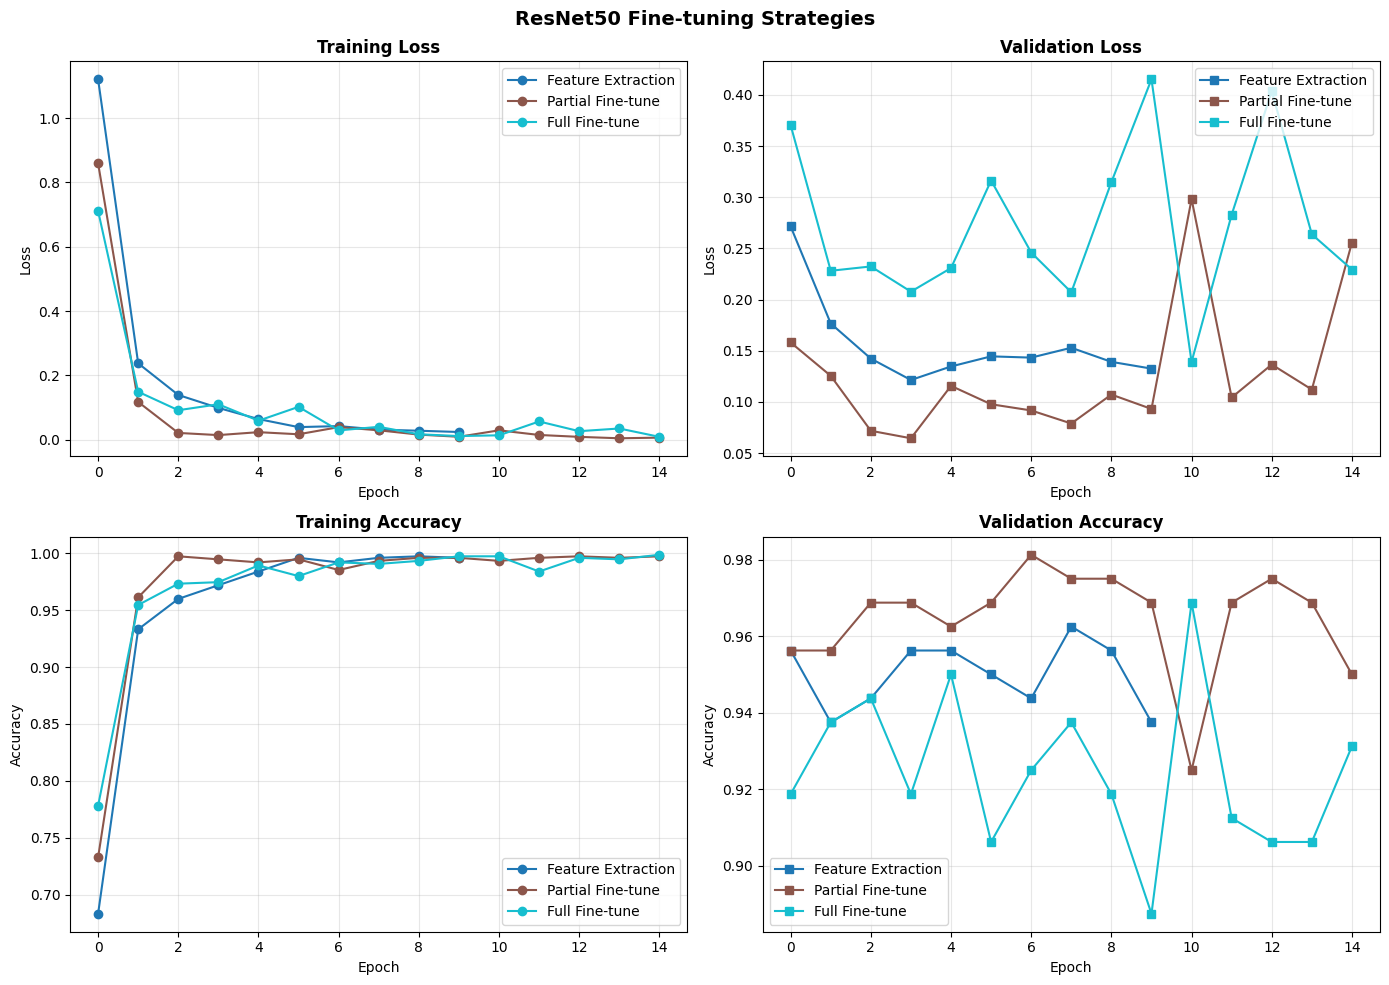

In [ ]:
# Plot ResNet50 experiments comparison
plot_comparison(
    [history_resnet_frozen, history_resnet_partial, history_resnet_full],
    ['Feature Extraction', 'Partial Fine-tune', 'Full Fine-tune'],
    title="ResNet50 Fine-tuning Strategies"
)